# Week 8 - K-Nearest Neighbors

This notebook applies k-nearest neighbors to the capstone credit-risk dataset, carrying forward
the cleaning recipe and the stratified split used in every earlier notebook. Where the tree-based
models of Weeks 6 and 9 partition the feature space with axis-aligned splits, KNN makes no model
of the data at all. It answers a new borrower by finding the applicants who look most like them
and taking a vote. That single change of posture makes two questions unavoidable: what counts as
"close" in a space that mixes dollars, years, and percentages, and how many neighbours should be
allowed to vote.

The week is organised around those two questions. Sections 4 through 9 work through scaling, the
choice of k, five different distance metrics, neighbour weighting, and the effect of the encoded
feature space on distance. Sections 10 through 14 tune the model, evaluate it honestly on held-out
data, and place it on the leaderboard beside the Week 6 random forest and the Week 9 gradient
boosting model.

In [1]:
%pip install -q pandas numpy matplotlib scikit-learn kagglehub


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import kagglehub

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

print(f"scikit-learn version: {sklearn.__version__}")
print("All imports successful.")

scikit-learn version: 1.9.0
All imports successful.


## 1. Data Loading and Cleaning

The cleaning recipe is unchanged from Week 1 and is reused here without modification so that every
number in this notebook is comparable with the earlier weeks: median imputation for the
right-skewed employment length, grade-matched median imputation for the missing interest rates, and
removal of logically impossible records rather than merely unusual ones.

In [3]:
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
df = pd.read_csv(f"{path}/credit_risk_dataset.csv")

print(f"Raw shape: {df.shape}")

df = df.drop_duplicates().copy()

df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df.groupby("loan_grade")["loan_int_rate"].transform("median")
)

df = df[df["person_emp_length"] <= df["person_age"]]
df = df[df["person_age"] <= 100]
df = df[df["person_emp_length"] <= 60]

print(f"Clean shape: {df.shape}")
print(f"Default rate: {df['loan_status'].mean() * 100:.2f}%")
print("\nMissing values:")
print(df.isna().sum())

Raw shape: (32581, 12)
Clean shape: (32409, 12)
Default rate: 21.87%

Missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## 2. Classification Target and Feature Preparation

Two preprocessing paths are defined here rather than one. The scaled path standardises the six
numeric predictors and one-hot encodes the four categorical predictors; this is the path every KNN
model in the notebook uses. The unscaled path passes the numeric columns through untouched and is
kept for two purposes: to demonstrate in Section 4 what happens to a distance-based model when the
features are left on their native scales, and to feed the tree-based benchmarks in Section 14,
which are invariant to monotone rescaling and were fit on raw values in Weeks 6 and 9.

Both preprocessing steps live inside scikit-learn pipelines. This matters more for KNN than it did
for gradient boosting: a scaler fit on the full training set before cross-validation would leak the
validation folds' means and standard deviations into the distance calculation, and distance is the
entire model.

In [4]:
numeric_features = [
    "person_income",
    "person_age",
    "person_emp_length",
    "loan_amnt",
    "loan_percent_income",
    "loan_int_rate"
]

categorical_features = [
    "loan_intent",
    "loan_grade",
    "person_home_ownership",
    "cb_person_default_on_file"
]

X = df[numeric_features + categorical_features].copy()
y = df["loan_status"].copy()

complete_mask = X.notna().all(axis=1)
X = X.loc[complete_mask]
y = y.loc[complete_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

unscaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

numeric_only_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ]
)

X_train_enc = unscaled_preprocessor.fit_transform(X_train)
X_test_enc = unscaled_preprocessor.transform(X_test)

categorical_names = (
    unscaled_preprocessor.named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
feature_names = numeric_features + categorical_names

X_train_enc = np.asarray(X_train_enc, dtype=np.float32)
X_test_enc = np.asarray(X_test_enc, dtype=np.float32)

train_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print(f"Encoded features: {len(feature_names)}")
print(f"Training observations: {len(y_train):,}")
print(f"Testing observations: {len(y_test):,}")
print(f"Training default rate: {y_train.mean() * 100:.2f}%")
print(f"Testing default rate: {y_test.mean() * 100:.2f}%")

Encoded features: 25
Training observations: 25,927
Testing observations: 6,482
Training default rate: 21.87%
Testing default rate: 21.88%


### The scale problem, quantified

Before fitting anything, it is worth measuring how unequal the raw feature scales are. Euclidean
distance sums squared differences across features, so a feature whose values span tens of thousands
contributes millions to a squared distance while a feature spanning zero to one contributes
fractions. The ratio below is the size of the problem.

In [5]:
scale_summary = pd.DataFrame({
    "Feature": numeric_features,
    "Minimum": [X_train[column].min() for column in numeric_features],
    "Maximum": [X_train[column].max() for column in numeric_features],
    "Standard Deviation": [X_train[column].std() for column in numeric_features]
})

scale_summary["Range"] = (
    scale_summary["Maximum"]
    - scale_summary["Minimum"]
)

scale_summary = scale_summary.sort_values(
    "Standard Deviation",
    ascending=False
)

print("Raw Numeric Feature Scales")
print(scale_summary.round(3).to_string(index=False))

largest_std = scale_summary["Standard Deviation"].max()
smallest_std = scale_summary["Standard Deviation"].min()

print(
    "\nRatio of largest to smallest standard deviation:",
    f"{largest_std / smallest_std:,.0f} to 1"
)
print(
    "Without standardisation, one feature would dominate every "
    "distance computation in this notebook."
)

Raw Numeric Feature Scales
            Feature  Minimum    Maximum  Standard Deviation      Range
      person_income  4080.00 2039784.00           52539.326 2035704.00
          loan_amnt   500.00   35000.00            6293.701   34500.00
         person_age    20.00      94.00               6.164      74.00
  person_emp_length     0.00      38.00               3.969      38.00
      loan_int_rate     5.42      23.22               3.212      17.80
loan_percent_income     0.00       0.83               0.107       0.83

Ratio of largest to smallest standard deviation: 492,295 to 1
Without standardisation, one feature would dominate every distance computation in this notebook.


## 3. Reusable Evaluation Function

The same evaluation function used in Week 9 is reused unchanged. Accuracy is reported but is not the
deciding metric: with defaults at roughly one borrower in five, a model that approves every applicant
scores about 78 percent accuracy while catching no defaults at all. ROC AUC measures how well the
model ranks risk across all thresholds, and average precision summarises performance on the minority
default class specifically, which is the class the lender actually cares about.

In [6]:
def evaluate_classifier(
    model_name,
    model,
    X_eval,
    y_eval,
    threshold=0.50
):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    results = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, predictions),
        "ROC AUC": roc_auc_score(y_eval, probabilities),
        "Average Precision": average_precision_score(y_eval, probabilities),
        "Default Precision": precision_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "Default Recall": recall_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "Default F1": f1_score(
            y_eval,
            predictions,
            zero_division=0
        )
    }

    return results, probabilities, predictions


def build_knn_pipeline(preprocessor, **knn_settings):
    return Pipeline(
        steps=[
            ("prep", preprocessor),
            (
                "knn",
                KNeighborsClassifier(
                    n_jobs=-1,
                    **knn_settings
                )
            )
        ]
    )


def cross_validated_scores(
    pipeline,
    X_data,
    y_data,
    n_splits=4
):
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    auc_scores = cross_val_score(
        pipeline,
        X_data,
        y_data,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    return auc_scores.mean(), auc_scores.std()

## 4. Why a Distance-Based Model Requires Scaling

Week 4 established that scaling mattered for logistic regression, but there the consequence was
slower convergence and coefficients that could not be compared. For KNN the consequence is more
fundamental. If one feature dominates the distance metric, then "nearest neighbour" collapses into
"nearest on that one feature," and the remaining predictors are effectively discarded no matter how
informative they are. The experiment below fixes k and the metric and changes only whether the
numeric columns were standardised.

Effect of Feature Scaling on KNN
        Preprocessing  CV AUC Mean  CV AUC Std  Test AUC  Test Average Precision  Default Recall
    Unscaled features       0.8199      0.0037    0.8162                  0.6235          0.4492
Standardised features       0.8893      0.0018    0.8941                  0.8029          0.5959

Standardisation changes test AUC by +0.0780.


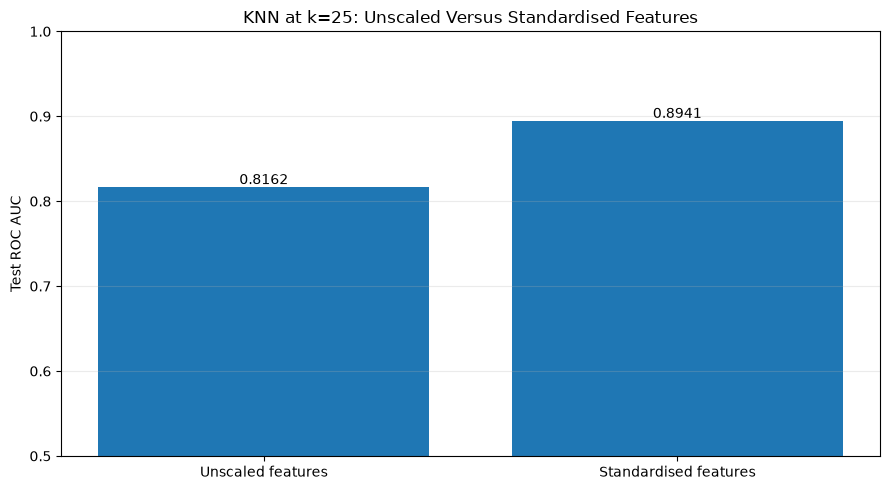

In [7]:
scaling_comparison_results = []

scaling_configurations = [
    ("Unscaled features", unscaled_preprocessor),
    ("Standardised features", scaled_preprocessor)
]

for label, preprocessor in scaling_configurations:
    pipeline = build_knn_pipeline(
        preprocessor=preprocessor,
        n_neighbors=25,
        metric="minkowski",
        p=2,
        weights="uniform"
    )

    mean_auc, std_auc = cross_validated_scores(
        pipeline=pipeline,
        X_data=X_train,
        y_data=y_train,
        n_splits=4
    )

    pipeline.fit(X_train, y_train)

    test_results, _, _ = evaluate_classifier(
        model_name=f"KNN (k=25) - {label}",
        model=pipeline,
        X_eval=X_test,
        y_eval=y_test
    )

    scaling_comparison_results.append({
        "Preprocessing": label,
        "CV AUC Mean": mean_auc,
        "CV AUC Std": std_auc,
        "Test AUC": test_results["ROC AUC"],
        "Test Average Precision": test_results["Average Precision"],
        "Default Recall": test_results["Default Recall"]
    })

scaling_comparison_df = pd.DataFrame(scaling_comparison_results)

print("Effect of Feature Scaling on KNN")
print(scaling_comparison_df.round(4).to_string(index=False))

scaling_gain = (
    scaling_comparison_df.loc[1, "Test AUC"]
    - scaling_comparison_df.loc[0, "Test AUC"]
)

print(
    f"\nStandardisation changes test AUC by {scaling_gain:+.4f}."
)

plt.figure(figsize=(9, 5))
plt.bar(
    scaling_comparison_df["Preprocessing"],
    scaling_comparison_df["Test AUC"]
)
for index, value in enumerate(scaling_comparison_df["Test AUC"]):
    plt.text(
        index,
        value + 0.004,
        f"{value:.4f}",
        ha="center"
    )
plt.ylabel("Test ROC AUC")
plt.ylim(0.5, 1.0)
plt.title("KNN at k=25: Unscaled Versus Standardised Features")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Choosing k with Cross-Validation

The number of neighbours is the bias-variance dial for this model family, and it is the most
directly interpretable hyperparameter in the entire capstone. At k=1 the model is a lookup table
with no smoothing: every training point is its own authority, and the decision boundary follows
every local accident in the data. As k grows, each prediction averages over a wider neighbourhood,
the boundary smooths, and the model becomes progressively less willing to commit to small pockets of
risk. Past some point the neighbourhood grows wide enough to blur genuine distinctions between
borrower types.

Cross-validation on the training set locates that point without consulting the test set.

Cross-Validated AUC by Number of Neighbours
 Neighbours  CV AUC Mean  CV AUC Std
          1       0.7767      0.0037
          3       0.8458      0.0028
          5       0.8631      0.0033
          9       0.8790      0.0016
         15       0.8857      0.0014
         21       0.8886      0.0014
         25       0.8893      0.0018
         31       0.8899      0.0012
         41       0.8903      0.0008
         51       0.8903      0.0009

Best k by cross-validated AUC: 51 (CV AUC = 0.8903)


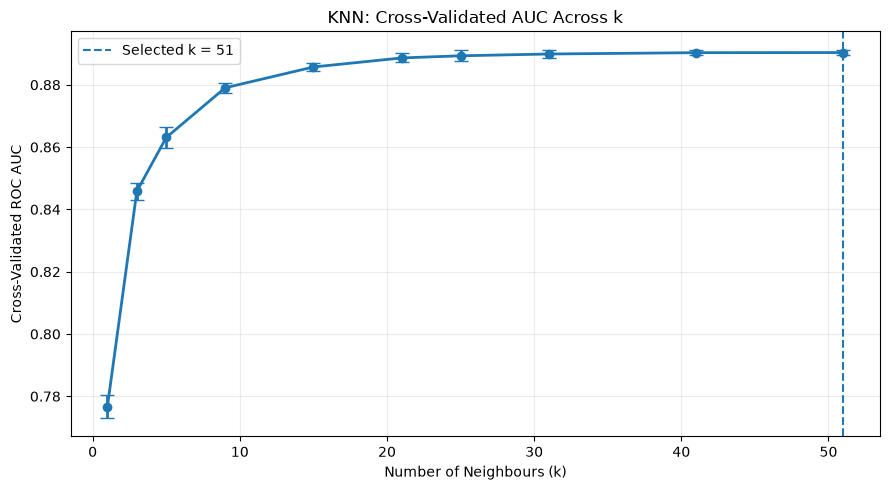

In [8]:
neighbour_values = [1, 3, 5, 9, 15, 21, 25, 31, 41, 51]

neighbour_results = []

for k in neighbour_values:
    pipeline = build_knn_pipeline(
        preprocessor=scaled_preprocessor,
        n_neighbors=k,
        metric="minkowski",
        p=2,
        weights="uniform"
    )

    mean_auc, std_auc = cross_validated_scores(
        pipeline=pipeline,
        X_data=X_train,
        y_data=y_train,
        n_splits=4
    )

    neighbour_results.append({
        "Neighbours": k,
        "CV AUC Mean": mean_auc,
        "CV AUC Std": std_auc
    })

neighbour_df = pd.DataFrame(neighbour_results)

print("Cross-Validated AUC by Number of Neighbours")
print(neighbour_df.round(4).to_string(index=False))

best_neighbour_row = neighbour_df.loc[
    neighbour_df["CV AUC Mean"].idxmax()
]

best_k = int(best_neighbour_row["Neighbours"])

print(
    f"\nBest k by cross-validated AUC: {best_k} "
    f"(CV AUC = {best_neighbour_row['CV AUC Mean']:.4f})"
)

plt.figure(figsize=(9, 5))
plt.errorbar(
    neighbour_df["Neighbours"],
    neighbour_df["CV AUC Mean"],
    yerr=neighbour_df["CV AUC Std"],
    marker="o",
    capsize=5,
    linewidth=2
)
plt.axvline(
    best_k,
    linestyle="--",
    label=f"Selected k = {best_k}"
)
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Cross-Validated ROC AUC")
plt.title("KNN: Cross-Validated AUC Across k")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. The Overfitting Signature of Small k

KNN has no coefficients to penalise and no trees to prune, so the overfitting controls available in
earlier weeks do not apply. The value of k *is* the regularisation. This section makes that concrete
by plotting training and test AUC side by side across k.

The expected behaviour at k=1 is distinctive and worth stating in advance: every training point is
its own nearest neighbour, so training AUC should be essentially perfect while test AUC sits far
below it. That gap is not a defect in the code, it is the definition of memorisation, and it is the
same diagnostic the Week 6 decision tree produced as depth increased and the Week 9 boosting model
produced as trees accumulated.

Training Versus Test AUC Across k
 Neighbours  Train AUC  Test AUC  Train Minus Test
          1     1.0000    0.7841            0.2159
          5     0.9635    0.8658            0.0977
         15     0.9354    0.8866            0.0488
         25     0.9238    0.8941            0.0297
         41     0.9140    0.8934            0.0206

The train-test gap at k=1: 0.2159
The train-test gap at the widest neighbourhood tested: 0.0206


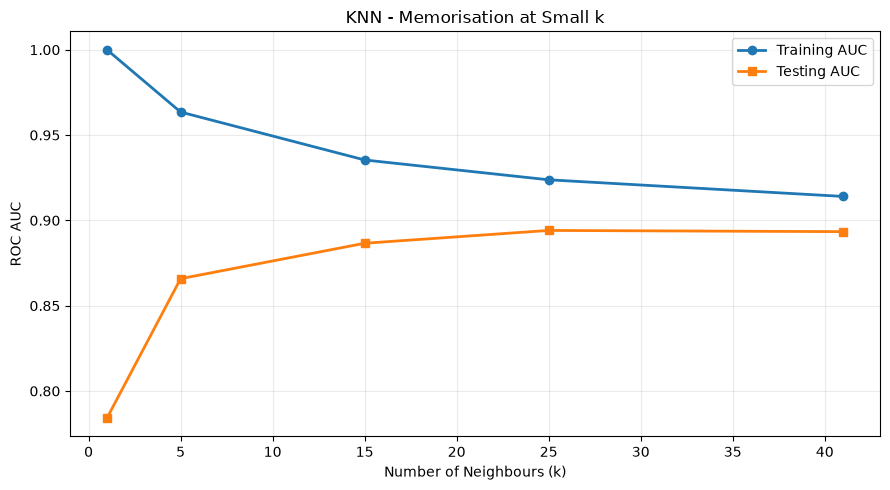

In [9]:
diagnostic_neighbour_values = [1, 5, 15, 25, 41]

diagnostic_results = []

for k in diagnostic_neighbour_values:
    pipeline = build_knn_pipeline(
        preprocessor=scaled_preprocessor,
        n_neighbors=k,
        metric="minkowski",
        p=2,
        weights="uniform"
    )

    pipeline.fit(X_train, y_train)

    train_probabilities = pipeline.predict_proba(X_train)[:, 1]
    test_probabilities = pipeline.predict_proba(X_test)[:, 1]

    diagnostic_results.append({
        "Neighbours": k,
        "Train AUC": roc_auc_score(y_train, train_probabilities),
        "Test AUC": roc_auc_score(y_test, test_probabilities)
    })

diagnostic_df = pd.DataFrame(diagnostic_results)
diagnostic_df["Train Minus Test"] = (
    diagnostic_df["Train AUC"]
    - diagnostic_df["Test AUC"]
)

print("Training Versus Test AUC Across k")
print(diagnostic_df.round(4).to_string(index=False))

print(
    "\nThe train-test gap at k=1:",
    f"{diagnostic_df.loc[0, 'Train Minus Test']:.4f}"
)
print(
    "The train-test gap at the widest neighbourhood tested:",
    f"{diagnostic_df.iloc[-1]['Train Minus Test']:.4f}"
)

plt.figure(figsize=(9, 5))
plt.plot(
    diagnostic_df["Neighbours"],
    diagnostic_df["Train AUC"],
    marker="o",
    linewidth=2,
    label="Training AUC"
)
plt.plot(
    diagnostic_df["Neighbours"],
    diagnostic_df["Test AUC"],
    marker="s",
    linewidth=2,
    label="Testing AUC"
)
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("ROC AUC")
plt.title("KNN - Memorisation at Small k")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Distance Metric Comparison

This is the week's central question. Every metric below is a different answer to "what does it mean
for two loan applications to be similar," and each one weights disagreements differently:

- **Euclidean (Minkowski p=2)** takes the straight-line distance and, because differences are
  squared, is dominated by the feature on which two borrowers differ most.
- **Manhattan (Minkowski p=1)** sums absolute differences, treating a large gap on one feature as
  equivalent to several modest gaps spread across many. It is generally the more robust choice when
  the data contain outliers, which the income distribution here certainly does.
- **Minkowski p=3** pushes further in the euclidean direction, weighting the single largest
  disagreement even more heavily.
- **Chebyshev** takes this to its limit and considers *only* the largest single-feature difference,
  discarding all other information.
- **Cosine** ignores magnitude entirely and compares direction. Two borrowers with the same profile
  shape at different absolute scales are treated as neighbours.

The comparison is run on a stratified subsample of the training data. Manhattan and Chebyshev cannot
use the same optimised routines as euclidean distance, and the full four-fold comparison across five
metrics would be prohibitively slow otherwise. The subsample preserves the class balance, and the
leading metric is re-confirmed on the full training set in Section 10.

Metric comparison subsample: 12,000 borrowers
Subsample default rate: 21.87%

Distance Metric Comparison at k=51
Distance Metric  CV AUC Mean  CV AUC Std
Manhattan (p=1)       0.8908      0.0065
Euclidean (p=2)       0.8860      0.0077
         Cosine       0.8843      0.0061
Minkowski (p=3)       0.8827      0.0070
      Chebyshev       0.8566      0.0064

Strongest metric: Manhattan (p=1)
Spread between best and worst metric: 0.0343 AUC


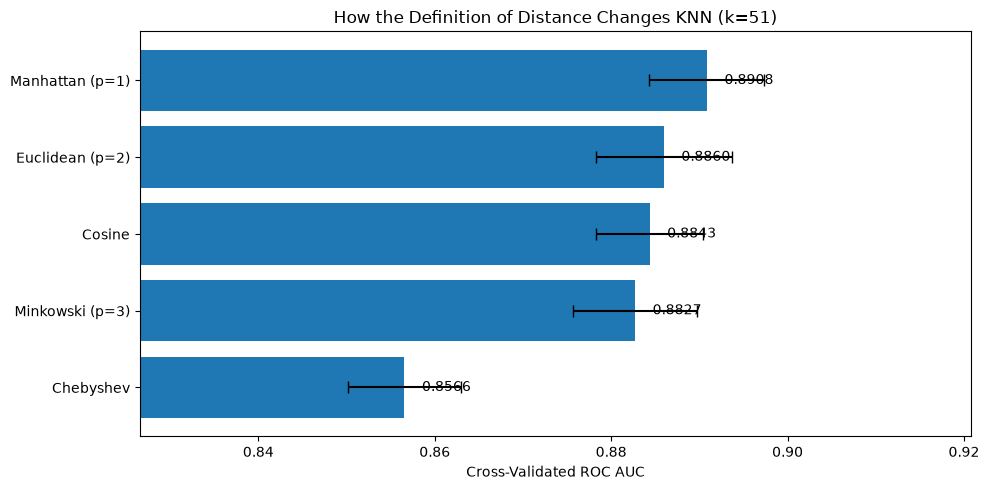

In [10]:
metric_subsample_size = 12000

subsample_indices, _ = train_test_split(
    np.arange(len(y_train)),
    train_size=metric_subsample_size,
    random_state=42,
    stratify=np.asarray(y_train)
)

X_metric = X_train.iloc[subsample_indices]
y_metric = y_train.iloc[subsample_indices]

print(f"Metric comparison subsample: {len(y_metric):,} borrowers")
print(f"Subsample default rate: {y_metric.mean() * 100:.2f}%")

distance_metric_settings = [
    {
        "Label": "Manhattan (p=1)",
        "Settings": {"metric": "minkowski", "p": 1}
    },
    {
        "Label": "Euclidean (p=2)",
        "Settings": {"metric": "minkowski", "p": 2}
    },
    {
        "Label": "Minkowski (p=3)",
        "Settings": {"metric": "minkowski", "p": 3}
    },
    {
        "Label": "Chebyshev",
        "Settings": {"metric": "chebyshev"}
    },
    {
        "Label": "Cosine",
        "Settings": {"metric": "cosine", "algorithm": "brute"}
    }
]

metric_results = []

for entry in distance_metric_settings:
    pipeline = build_knn_pipeline(
        preprocessor=scaled_preprocessor,
        n_neighbors=best_k,
        weights="uniform",
        **entry["Settings"]
    )

    mean_auc, std_auc = cross_validated_scores(
        pipeline=pipeline,
        X_data=X_metric,
        y_data=y_metric,
        n_splits=4
    )

    metric_results.append({
        "Distance Metric": entry["Label"],
        "CV AUC Mean": mean_auc,
        "CV AUC Std": std_auc
    })

metric_df = pd.DataFrame(metric_results).sort_values(
    "CV AUC Mean",
    ascending=False
).reset_index(drop=True)

print(f"\nDistance Metric Comparison at k={best_k}")
print(metric_df.round(4).to_string(index=False))

best_metric_label = metric_df.loc[0, "Distance Metric"]
metric_spread = (
    metric_df["CV AUC Mean"].max()
    - metric_df["CV AUC Mean"].min()
)

print(f"\nStrongest metric: {best_metric_label}")
print(f"Spread between best and worst metric: {metric_spread:.4f} AUC")

metric_order = metric_df.sort_values("CV AUC Mean")

plt.figure(figsize=(10, 5))
plt.barh(
    metric_order["Distance Metric"],
    metric_order["CV AUC Mean"],
    xerr=metric_order["CV AUC Std"],
    capsize=4
)
for index, value in enumerate(metric_order["CV AUC Mean"]):
    plt.text(
        value + 0.002,
        index,
        f"{value:.4f}",
        va="center"
    )
plt.xlabel("Cross-Validated ROC AUC")
plt.title(f"How the Definition of Distance Changes KNN (k={best_k})")
plt.xlim(
    metric_order["CV AUC Mean"].min() - 0.03,
    metric_order["CV AUC Mean"].max() + 0.03
)
plt.tight_layout()
plt.show()

## 8. Uniform Versus Distance Weighting

Uniform weighting gives every one of the k neighbours an equal vote, which means the fifty-first
closest borrower counts as much as the closest one. Distance weighting instead weights each vote by
the inverse of its distance, so genuinely similar applicants dominate the prediction and marginal
ones fade out.

There is a second reason to test this on an imbalanced problem. KNN accepts no class weights and no
sample weights, so the rebalancing lever used in Weeks 4, 6, and 9 is simply unavailable here.
Distance weighting is the closest substitute: in a mixed neighbourhood, a nearby default carries
more influence than several distant repayments.

Neighbour Weighting Comparison
 Neighbours Weighting  CV AUC Mean  CV AUC Std
         15   uniform       0.8857      0.0014
         15  distance       0.8897      0.0015
         25   uniform       0.8893      0.0018
         25  distance       0.8939      0.0016
         41   uniform       0.8903      0.0008
         41  distance       0.8954      0.0004

Distance Weighting Advantage by k
Weighting   distance  uniform  Distance Advantage
Neighbours                                       
15            0.8897   0.8857              0.0040
25            0.8939   0.8893              0.0046
41            0.8954   0.8903              0.0051


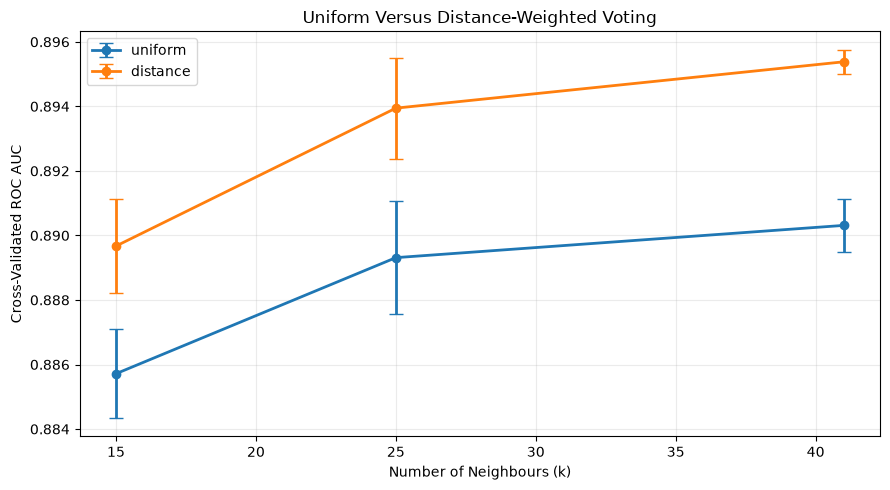

In [11]:
weighting_neighbour_values = [15, 25, 41]

weighting_results = []

for k in weighting_neighbour_values:
    for weighting in ["uniform", "distance"]:
        pipeline = build_knn_pipeline(
            preprocessor=scaled_preprocessor,
            n_neighbors=k,
            metric="minkowski",
            p=2,
            weights=weighting
        )

        mean_auc, std_auc = cross_validated_scores(
            pipeline=pipeline,
            X_data=X_train,
            y_data=y_train,
            n_splits=4
        )

        weighting_results.append({
            "Neighbours": k,
            "Weighting": weighting,
            "CV AUC Mean": mean_auc,
            "CV AUC Std": std_auc
        })

weighting_df = pd.DataFrame(weighting_results)

print("Neighbour Weighting Comparison")
print(weighting_df.round(4).to_string(index=False))

weighting_pivot = weighting_df.pivot(
    index="Neighbours",
    columns="Weighting",
    values="CV AUC Mean"
)

weighting_pivot["Distance Advantage"] = (
    weighting_pivot["distance"]
    - weighting_pivot["uniform"]
)

print("\nDistance Weighting Advantage by k")
print(weighting_pivot.round(4).to_string())

plt.figure(figsize=(9, 5))
for weighting in ["uniform", "distance"]:
    subset = weighting_df[weighting_df["Weighting"] == weighting]
    plt.errorbar(
        subset["Neighbours"],
        subset["CV AUC Mean"],
        yerr=subset["CV AUC Std"],
        marker="o",
        capsize=5,
        linewidth=2,
        label=weighting
    )
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Cross-Validated ROC AUC")
plt.title("Uniform Versus Distance-Weighted Voting")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Dimensionality and the Encoded Feature Space

One-hot encoding the four categorical predictors expands six numeric columns into a
twenty-five-dimensional space, nineteen dimensions of which are binary indicators. This is
harmless for trees, which simply ignore uninformative splits, but it is not obviously harmless for
KNN. In higher dimensions the distances between all pairs of points converge toward one another, so
the notion of a distinctly close neighbour weakens. Every binary indicator also contributes a fixed
quantum to the distance whenever two borrowers differ on it, regardless of how predictive that
category actually is.

The question is therefore empirical: do the encoded categoricals earn their place in the distance
metric, or do they dilute it? This section compares the six standardised numeric features alone
against the full encoded space.

In [12]:
feature_space_configurations = [
    (
        "Numeric only (6 features)",
        numeric_only_preprocessor
    ),
    (
        f"Numeric plus one-hot ({len(feature_names)} features)",
        scaled_preprocessor
    )
]

feature_space_results = []

for label, preprocessor in feature_space_configurations:
    pipeline = build_knn_pipeline(
        preprocessor=preprocessor,
        n_neighbors=best_k,
        metric="minkowski",
        p=2,
        weights="distance"
    )

    mean_auc, std_auc = cross_validated_scores(
        pipeline=pipeline,
        X_data=X_train,
        y_data=y_train,
        n_splits=4
    )

    pipeline.fit(X_train, y_train)

    test_results, _, _ = evaluate_classifier(
        model_name=f"KNN - {label}",
        model=pipeline,
        X_eval=X_test,
        y_eval=y_test
    )

    feature_space_results.append({
        "Feature Space": label,
        "CV AUC Mean": mean_auc,
        "CV AUC Std": std_auc,
        "Test AUC": test_results["ROC AUC"],
        "Test Average Precision": test_results["Average Precision"]
    })

feature_space_df = pd.DataFrame(feature_space_results)

print("Effect of the Encoded Feature Space on KNN")
print(feature_space_df.round(4).to_string(index=False))

feature_space_difference = (
    feature_space_df.loc[1, "CV AUC Mean"]
    - feature_space_df.loc[0, "CV AUC Mean"]
)

print(
    "\nAdding the one-hot categoricals changes CV AUC by",
    f"{feature_space_difference:+.4f}."
)

if feature_space_difference > 0.002:
    selected_preprocessor = scaled_preprocessor
    selected_space_label = "numeric plus one-hot"
    print(
        "[Inference] The categorical indicators contribute usable signal "
        "to the distance metric and are retained."
    )
elif feature_space_difference < -0.002:
    selected_preprocessor = numeric_only_preprocessor
    selected_space_label = "numeric only"
    print(
        "[Inference] The categorical indicators dilute the distance metric. "
        "The numeric-only space is the better representation for KNN."
    )
else:
    selected_preprocessor = scaled_preprocessor
    selected_space_label = "numeric plus one-hot"
    print(
        "[Inference] The two feature spaces are effectively tied, so the "
        "fuller representation is retained for comparability with the "
        "tree-based models of Weeks 6 and 9."
    )

print(f"Feature space carried into tuning: {selected_space_label}")

Effect of the Encoded Feature Space on KNN
                     Feature Space  CV AUC Mean  CV AUC Std  Test AUC  Test Average Precision
         Numeric only (6 features)       0.8817      0.0012    0.8884                  0.7588
Numeric plus one-hot (25 features)       0.8955      0.0003    0.9003                  0.8199

Adding the one-hot categoricals changes CV AUC by +0.0138.
[Inference] The categorical indicators contribute usable signal to the distance metric and are retained.
Feature space carried into tuning: numeric plus one-hot


## 10. Hyperparameter Tuning with Stratified Cross-Validation

The grid search below tunes the three hyperparameters that Sections 5 through 8 examined one at a
time, allowing them to interact. The two parameter blocks exist because Minkowski distance takes a
`p` value while cosine distance does not, and cosine similarity additionally requires brute-force
neighbour search rather than a tree structure.

Every fold is stratified so that each validation set carries the same roughly one-in-five default
rate as the full data. Both ROC AUC and average precision are computed, and the model is refit on
AUC. Training scores are returned alongside validation scores so that the gap between them can be
read directly off the results table, which is the same overfitting check applied in Week 9.

In [13]:
parameter_grid = [
    {
        "knn__n_neighbors": [15, 25, 35],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["minkowski"],
        "knn__p": [1, 2]
    },
    {
        "knn__n_neighbors": [15, 25, 35],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["cosine"],
        "knn__algorithm": ["brute"]
    }
]

base_search_pipeline = build_knn_pipeline(
    preprocessor=selected_preprocessor
)

stratified_cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

knn_search = GridSearchCV(
    estimator=base_search_pipeline,
    param_grid=parameter_grid,
    scoring={
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    refit="roc_auc",
    cv=stratified_cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

knn_search.fit(X_train, y_train)

print("\nBest Parameters")
print(knn_search.best_params_)
print(f"\nBest Cross-Validated AUC: {knn_search.best_score_:.4f}")

search_results = pd.DataFrame(knn_search.cv_results_)

search_summary = search_results[
    [
        "rank_test_roc_auc",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "mean_test_average_precision",
        "mean_train_roc_auc",
        "params"
    ]
].sort_values("rank_test_roc_auc").head(10)

print("\nTop Hyperparameter Combinations")
print(search_summary.round(4).to_string(index=False))

best_row = search_results.loc[
    search_results["rank_test_roc_auc"].idxmin()
]

print(
    "\nTrain minus validation AUC for the selected model:",
    f"{best_row['mean_train_roc_auc'] - best_row['mean_test_roc_auc']:+.4f}"
)

Fitting 4 folds for each of 18 candidates, totalling 72 fits


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {SIGTERM(-15)}
Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

## 11. Evaluate the Tuned KNN Model

The selected configuration now meets the held-out test set for the first time. Everything up to this
point was decided using cross-validation on the training data only, so these figures are an honest
estimate of performance on borrowers the model has never seen.

In [ ]:
best_knn = knn_search.best_estimator_

tuned_results, tuned_probabilities, tuned_predictions = evaluate_classifier(
    model_name="Tuned KNN",
    model=best_knn,
    X_eval=X_test,
    y_eval=y_test,
    threshold=0.50
)

print("Tuned KNN")
print("-" * 40)

for metric, value in tuned_results.items():
    if metric not in ["Model", "Threshold"]:
        print(f"{metric:<22}: {value:.4f}")

print("\nClassification Report")
print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=["Repaid", "Default"]
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_predictions,
    display_labels=["Repaid", "Default"],
    values_format=",d"
)
plt.title("Tuned KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    tuned_probabilities
)

plt.figure(figsize=(7, 5))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2.5,
    label=f"KNN AUC = {tuned_results['ROC AUC']:.4f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned KNN - ROC Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

test_precision_curve, test_recall_curve, _ = precision_recall_curve(
    y_test,
    tuned_probabilities
)

plt.figure(figsize=(7, 5))
plt.plot(
    test_recall_curve,
    test_precision_curve,
    linewidth=2.5,
    label=(
        "Average Precision = "
        f"{tuned_results['Average Precision']:.4f}"
    )
)
plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Default prevalence = {y_test.mean():.3f}"
)
plt.xlabel("Default Recall")
plt.ylabel("Default Precision")
plt.title("Tuned KNN - Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 12. Selecting a Classification Threshold on Validation Data

A KNN probability is a neighbourhood vote share, so with k neighbours the model can only produce
k+1 distinct probability values. The threshold therefore behaves more coarsely here than it did for
gradient boosting, and it is worth checking where the achievable operating points actually fall.

As in Week 9, the threshold is chosen on a validation split carved out of the training data, never on
the test set. Choosing a threshold by looking at test performance would quietly convert the test set
into a tuning set and inflate every number reported above it.

In [ ]:
y_train_array = np.asarray(y_train)
all_training_indices = np.arange(len(y_train_array))

threshold_fit_indices, threshold_validation_indices = train_test_split(
    all_training_indices,
    test_size=0.20,
    random_state=42,
    stratify=y_train_array
)

threshold_model = clone(best_knn)

threshold_model.fit(
    X_train.iloc[threshold_fit_indices],
    y_train_array[threshold_fit_indices]
)

validation_probabilities = threshold_model.predict_proba(
    X_train.iloc[threshold_validation_indices]
)[:, 1]

print(
    "Distinct probability values available from this neighbourhood vote:",
    f"{len(np.unique(validation_probabilities))}"
)

validation_precision, validation_recall, validation_thresholds = (
    precision_recall_curve(
        y_train_array[threshold_validation_indices],
        validation_probabilities
    )
)

validation_f1 = (
    2
    * validation_precision[:-1]
    * validation_recall[:-1]
    / (
        validation_precision[:-1]
        + validation_recall[:-1]
        + 1e-12
    )
)

best_threshold_index = int(np.nanargmax(validation_f1))
selected_threshold = float(
    validation_thresholds[best_threshold_index]
)

print(f"\nValidation-selected threshold: {selected_threshold:.4f}")
print(
    "Validation F1 at selected threshold:",
    f"{validation_f1[best_threshold_index]:.4f}"
)

threshold_results, _, threshold_predictions = evaluate_classifier(
    model_name="Tuned KNN - Validation Threshold",
    model=best_knn,
    X_eval=X_test,
    y_eval=y_test,
    threshold=selected_threshold
)

threshold_comparison = pd.DataFrame(
    [tuned_results, threshold_results]
)

print("\nThreshold Comparison")
print(
    threshold_comparison[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Balanced Accuracy",
            "Default Precision",
            "Default Recall",
            "Default F1"
        ]
    ].round(4).to_string(index=False)
)

print("\nClassification Report at Validation-Selected Threshold")
print(
    classification_report(
        y_test,
        threshold_predictions,
        target_names=["Repaid", "Default"]
    )
)

plt.figure(figsize=(9, 5))
plt.plot(
    validation_thresholds,
    validation_precision[:-1],
    label="Precision"
)
plt.plot(
    validation_thresholds,
    validation_recall[:-1],
    label="Recall"
)
plt.plot(
    validation_thresholds,
    validation_f1,
    label="F1"
)
plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.3f}"
)
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("KNN Validation Threshold Trade-Off")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 13. Permutation Importance

KNN offers no coefficients and no impurity-based importances, so the only way to ask which features
matter is to break them one at a time and measure the damage. Permutation importance shuffles a
single column in the test set and records the resulting fall in AUC. Because the shuffling happens
before the pipeline's scaler, the reported values refer to the original interpretable columns rather
than to encoded indicator variables.

This is also the one importance measure that is directly comparable across every model family in the
capstone, which makes it the right instrument for asking whether KNN agrees with the Week 6 forest
and the Week 9 boosting model about what drives default.

In [ ]:
permutation_results = permutation_importance(
    estimator=best_knn,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Permutation Importance": permutation_results.importances_mean,
    "Importance Std": permutation_results.importances_std
}).sort_values(
    "Permutation Importance",
    ascending=False
)

print("KNN Permutation Importance")
print(permutation_importance_df.round(5).to_string(index=False))

top_permutation = permutation_importance_df.sort_values(
    "Permutation Importance"
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_permutation["Feature"],
    top_permutation["Permutation Importance"],
    xerr=top_permutation["Importance Std"],
    capsize=3
)
plt.xlabel("Decrease in Test ROC AUC When Permuted")
plt.title("Tuned KNN - Permutation Importance")
plt.tight_layout()
plt.show()

## 14. Benchmark Against Weeks 6 and 9

The final comparison rebuilds the Week 6 random forest and the Week 9 tuned gradient boosting model
on the identical split so that all three families can be read off one leaderboard. Both benchmarks
are fit on the unscaled encoded matrix, matching how they were originally specified: tree-based
models split on thresholds within individual features and are unaffected by standardisation.

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

random_forest.fit(
    X_train_enc,
    y_train
)

rf_results, rf_probabilities, rf_predictions = evaluate_classifier(
    model_name="Random Forest - Week 6 Specification",
    model=random_forest,
    X_eval=X_test_enc,
    y_eval=y_test,
    threshold=0.50
)

gradient_boosting = GradientBoostingClassifier(
    subsample=0.85,
    n_estimators=300,
    min_samples_leaf=3,
    max_features=None,
    max_depth=4,
    learning_rate=0.10,
    random_state=42
)

gradient_boosting.fit(
    X_train_enc,
    y_train,
    sample_weight=train_weights
)

gb_results, gb_probabilities, gb_predictions = evaluate_classifier(
    model_name="Gradient Boosting - Week 9 Specification",
    model=gradient_boosting,
    X_eval=X_test_enc,
    y_eval=y_test,
    threshold=0.50
)

model_comparison = pd.DataFrame([
    tuned_results,
    threshold_results,
    rf_results,
    gb_results
]).sort_values(
    "ROC AUC",
    ascending=False
).reset_index(drop=True)

comparison_columns = [
    "Model",
    "ROC AUC",
    "Average Precision",
    "Accuracy",
    "Balanced Accuracy",
    "Default Precision",
    "Default Recall",
    "Default F1"
]

print("Week 8 Model Leaderboard")
print(
    model_comparison[comparison_columns]
    .round(4)
    .to_string(index=False)
)

auc_order = model_comparison.sort_values("ROC AUC")

plt.figure(figsize=(10, 5))
plt.barh(
    auc_order["Model"],
    auc_order["ROC AUC"]
)
for index, value in enumerate(auc_order["ROC AUC"]):
    plt.text(
        value + 0.001,
        index,
        f"{value:.4f}",
        va="center"
    )
plt.xlabel("Test ROC AUC")
plt.title("KNN Compared with the Week 6 Forest and Week 9 Boosting Model")
plt.tight_layout()
plt.show()

ap_order = model_comparison.sort_values("Average Precision")

plt.figure(figsize=(10, 5))
plt.barh(
    ap_order["Model"],
    ap_order["Average Precision"]
)
for index, value in enumerate(ap_order["Average Precision"]):
    plt.text(
        value + 0.001,
        index,
        f"{value:.4f}",
        va="center"
    )
plt.xlabel("Test Average Precision")
plt.title("Model Comparison on the Minority Default Class")
plt.tight_layout()
plt.show()

knn_gb_difference = (
    tuned_results["ROC AUC"]
    - gb_results["ROC AUC"]
)

knn_rf_difference = (
    tuned_results["ROC AUC"]
    - rf_results["ROC AUC"]
)

print(
    f"\nTuned KNN minus Week 9 Gradient Boosting AUC: {knn_gb_difference:+.4f}"
)
print(
    f"Tuned KNN minus Week 6 Random Forest AUC: {knn_rf_difference:+.4f}"
)

if knn_gb_difference > 0.002:
    print(
        "[Inference] A purely local, memory-based method outranks the "
        "boosted ensemble on this test set, which would be a notable result "
        "for a model that fits no global structure whatsoever."
    )
elif knn_gb_difference < -0.002:
    print(
        "[Inference] Gradient boosting retains the stronger risk ranking. "
        "KNN recovers much of the available signal from local similarity "
        "alone, but the sequential ensemble captures feature interactions "
        "that neighbourhood voting cannot express."
    )
else:
    print(
        "[Inference] KNN and gradient boosting rank borrower risk almost "
        "identically, so prediction speed, interpretability, and the cost "
        "of storing the training set become the deciding criteria."
    )

print(
    "\n[Inference] KNN carries no trained parameters, so the entire training "
    "set must be retained and searched at prediction time. For a lender "
    "scoring applications in real time, that operational cost is a genuine "
    "consideration alongside AUC."
)

## 15. Week 8 Takeaways and the Bridge to Weeks 10 and 11

**What this week established:**

- Standardisation is not optional for a distance-based model. Section 2 measured the ratio between
  the largest and smallest numeric standard deviation, and Section 4 converted that imbalance into
  a measured AUC difference at fixed k.
- The choice of k is the entire regularisation story for this family. Section 6 reproduced the same
  train-versus-test divergence seen with tree depth in Week 6 and with accumulated trees in Week 9,
  from a completely different mechanism.
- The definition of distance is a modelling decision with measurable consequences. Section 7
  quantified the spread across five metrics, and Chebyshev's performance shows what is lost when a
  metric attends to only the single largest feature disagreement.
- KNN accepts neither class weights nor sample weights, so the imbalance lever used throughout the
  classification weeks is unavailable. Distance weighting and threshold selection are the
  substitutes, and Section 12 showed how coarse the achievable operating points become when
  probabilities are neighbourhood vote shares.

**The bridge forward.** This week's real contribution to the capstone is conceptual rather than
competitive. Whatever the leaderboard says, the exercise established that borrowers who resemble one
another on standardised attributes tend to share outcomes, which is precisely the premise the
unsupervised weeks depend on. Weeks 10 and 11 keep the distance machinery and the standardised
feature space built here and discard the labels entirely, asking whether the borrower population
falls into natural groups without being told what default looks like. The scaling decisions and the
metric comparison in this notebook are the direct foundation for the K-Means work that follows.